## LSTM Neural Network for Volatility Forecasting

In this notebook, we develop and evaluate a Long Short-Term Memory (LSTM) neural network to forecast the future realized volatility of 2800.HK. 

Imports

In [60]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

import os
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

### Load Processed Volatility & Return Data

We import the pre-exported datasets created and create features

In [61]:
log_ret = pd.read_excel('/Users/thijsmanuel/ECON4130_Term_Paper/data/hsi_log_ret.xlsx').set_index('date')
returns = log_ret['2800.HK']

features = pd.DataFrame(index=returns.index)

# Raw return features
features['ret'] = returns
features['ret_abs'] = returns.abs()
features['ret2'] = returns**2

# Short-, medium-, long-term vol windows
features['rv5']  = (returns**2).rolling(5).sum()
features['rv10'] = (returns**2).rolling(10).sum()
features['rv21'] = (returns**2).rolling(21).sum()

# Shocks & vol-of-vol
features['shock2'] = (returns**2).rolling(2).sum()
features['shock3'] = (returns**2).rolling(3).sum()
features['shock5'] = (returns**2).rolling(5).sum()
features['rv5_diff']  = features['rv5'].diff()
features['rv10_diff'] = features['rv10'].diff()
features['rv21_diff'] = features['rv21'].diff()

# Leverage effect
features['signed_shock'] = returns * returns.abs()

mu1 = np.sqrt(2 / np.pi)

abs_ret = returns.abs()
prod_abs = abs_ret * abs_ret.shift(1)  # |r_t| * |r_{t-1}|

def bipower_variation(prod_abs, window):
    return (1 / mu1**2) * prod_abs.rolling(window).sum()

features['bv5']  = bipower_variation(prod_abs, 5)
features['bv10'] = bipower_variation(prod_abs, 10)
features['bv21'] = bipower_variation(prod_abs, 21)

def realized_quarticity(ret, window):
    return (window / 3.0) * ret.pow(4).rolling(window).sum()

features['rq5']  = realized_quarticity(returns, 5)
features['rq10'] = realized_quarticity(returns, 10)
features['rq21'] = realized_quarticity(returns, 21)


# Target = 21-day future vol (less smooth)
target = (returns**2).rolling(21).sum().shift(-21)
target = 0.5 * np.log(target + 1e-12)
target.name = "y"

df = pd.concat([features, target], axis=1).dropna()

df # Quick display for sanity check 

### Train / Out-of-Sample Split and Feature Scaling

We split the dataset into in-sample and out-of-sample periods using a fixed
calendar cutoff.  
Feature scaling is performed **only on the training data** to prevent
information leakage, and the fitted scaler will later be applied to OOS data.

In [ ]:
# df: has all features + target y
oos = df[df.index >= '2022-01-01']
df = df[df.index < '2022-01-01']

X_in = df.drop(columns=["y"]).values
y_in = df["y"].values

scaler = StandardScaler()
X_in_scaled = scaler.fit_transform(X_in)


### Construct Supervised Sequences for LSTM Input

LSTMs require sequence-to-one training samples.  
We transform the realized volatility series into overlapping windows

In [64]:
def make_lstm_sequences(X, y, seq_len=60):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])  # shape: (seq_len, num_features)
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

### Prepare In-Sample Data for LSTM Training

We construct the training and validation datasets using **only in-sample data**

In [65]:
# In-sample period (before 2022) 
df_in = df[df.index < '2022-01-01']

X_in = df_in.drop(columns=["y"]).values
y_in = df_in["y"].values

# Scale only on in-sample 
scaler = StandardScaler()
X_in_scaled = scaler.fit_transform(X_in)

# Build LSTM sequences 
X_seq, y_seq = make_lstm_sequences(X_in_scaled, y_in, seq_len=120)

# Train / Validation split 
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_val   = X_seq[split:]

y_train = y_seq[:split]
y_val   = y_seq[split:]

# Convert to tensors 
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=64, shuffle=False)

val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor),
                          batch_size=64, shuffle=False)


### LSTM Model Architecture

We define a deep LSTM network for volatility forecasting.

In [66]:

class DeepVolLSTM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3,
        bidirectional: bool = False,
        use_layernorm: bool = True,
    ):
        """
        Deep LSTM model for volatility forecasting.

        Args:
            input_dim: number of features per timestep (1 for univariate series)
            hidden_dim: number of hidden units in each LSTM layer
            num_layers: number of stacked LSTM layers 
            dropout: dropout rate applied between LSTM layers and inside MLP
            bidirectional: whether to use a forward + backward LSTM
            use_layernorm: apply layer normalization for training stability
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # LSTM stack
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        lstm_out_dim = hidden_dim * self.num_directions

        # Optional normalization on top of LSTM output
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(lstm_out_dim)

        # MLP head for volatility mapping
        self.mlp = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, 2),   # output mean and log_variance
        )


    def forward(self, x: torch.Tensor):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]

        if self.use_layernorm:
            last_out = self.ln(last_out)

        vol_raw = self.mlp(last_out)  # (batch, 2)

        mean = vol_raw[:, 0]
        log_var = vol_raw[:, 1]

        return mean, log_var




### Instantiate the LSTM Model

We configure the LSTM

In [67]:
# Model architecture configuration
input_dim = X_in.shape[1]    # univariate volatility input
hidden_dim = 128   # model capacity per recurrent layer
num_layers = 5    # number of stacked LSTMs

# Initialize model for next-step volatility forecasting
model = DeepVolLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=0.3,
    bidirectional=False,  # causal (forward-only) forecasting
    use_layernorm=True,   # improve training stability
)

model  # show model architecture summary

DeepVolLSTM(
  (lstm): LSTM(19, 128, num_layers=5, batch_first=True, dropout=0.3)
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

### Model Training with Early Stopping and Learning Rate Scheduling

We train the LSTM using student t loss and Adam optimization.

In [68]:
import math
import torch

def student_t_nll(mean, log_var, target, nu: float = 5.0):
    """
    Negative log-likelihood of Student-t distribution.
    mean     : (batch,)
    log_var  : (batch,)
    target   : (batch,)
    nu       : degrees of freedom (>2)
    """
    var = torch.exp(log_var)
    sigma = torch.sqrt(var + 1e-12)

    z = (target - mean) / sigma

    # Convert nu → tensor (on correct device)
    nu_tensor = torch.tensor(nu, dtype=mean.dtype, device=mean.device)

    # Constant terms
    c1 = torch.lgamma((nu_tensor + 1.0) / 2.0) - torch.lgamma(nu_tensor / 2.0)
    c2 = 0.5 * (torch.log(nu_tensor * math.pi) + 2.0 * torch.log(sigma))

    # Main log term: 0.5*(nu+1)*log(1 + z^2 / nu)
    c3 = 0.5 * (nu_tensor + 1.0) * torch.log1p(z.pow(2) / nu_tensor)

    return (c1 + c2 + c3).mean()


In [69]:
# Optimizer and loss function
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=1e-4, 
    weight_decay=1e-5
    )
# loss_fn = nn.GaussianNLLLoss()

# Reduce LR by factor 2 when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,       # allow a few stagnant epochs
)

epochs = 100
early_stop_patience = 20 # avoid long overfitting runs
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        mean, log_var = model(x_batch)
        log_var = torch.clamp(log_var, -10, 5)

        loss = student_t_nll(mean, log_var, y_batch, nu=5.0)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            mean, log_var = model(x_val)
            log_var = torch.clamp(log_var, -10, 5)

            loss = student_t_nll(mean, log_var, y_val, nu=5.0)
            test_loss += loss.item()

    test_loss /= len(val_loader)

    # ---- LR + EARLY STOPPING ----
    scheduler.step(test_loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Test: {test_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if test_loss < best_val_loss - 1e-6:
        best_val_loss = test_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break


Epoch 01 | Train: 3.4793 | Test: 2.4634 | LR: 0.000100
Epoch 02 | Train: 2.1110 | Test: 1.3876 | LR: 0.000100
Epoch 03 | Train: 1.8674 | Test: 1.3080 | LR: 0.000100
Epoch 04 | Train: 1.8211 | Test: 1.2513 | LR: 0.000100
Epoch 05 | Train: 1.8250 | Test: 1.2562 | LR: 0.000100
Epoch 06 | Train: 1.7998 | Test: 1.2300 | LR: 0.000100
Epoch 07 | Train: 1.7911 | Test: 1.2021 | LR: 0.000100
Epoch 08 | Train: 1.7862 | Test: 1.2332 | LR: 0.000100
Epoch 09 | Train: 1.7407 | Test: 1.1948 | LR: 0.000100
Epoch 10 | Train: 1.7334 | Test: 1.1867 | LR: 0.000100
Epoch 11 | Train: 1.7099 | Test: 1.1700 | LR: 0.000100
Epoch 12 | Train: 1.6747 | Test: 1.1409 | LR: 0.000100
Epoch 13 | Train: 1.6349 | Test: 1.1306 | LR: 0.000100
Epoch 14 | Train: 1.6172 | Test: 1.1291 | LR: 0.000100
Epoch 15 | Train: 1.6211 | Test: 1.1156 | LR: 0.000100
Epoch 16 | Train: 1.6256 | Test: 1.1082 | LR: 0.000100
Epoch 17 | Train: 1.6134 | Test: 1.1178 | LR: 0.000100
Epoch 18 | Train: 1.6056 | Test: 1.1126 | LR: 0.000100
Epoch 19 |

### Prepare Out-of-Sample Data for Model Evaluation

In [84]:
oos_x = oos.drop(columns=['y']).values
oos_y = oos["y"].values

oos_x_scaled = scaler.transform(oos_x)

In [85]:
X_full_scaled = np.vstack([X_in_scaled, oos_x_scaled])
y_full = np.concatenate([y_in, oos_y])

# Build sequences on full dataset 
X_full_seq, y_full_seq = make_lstm_sequences(X_full_scaled, y_full, seq_len=120)

# Determine OOS starting index 
n_in = len(X_in_scaled)
start_idx = n_in - 60

X_oos_seq = X_full_seq[start_idx:]
y_oos_seq = y_full_seq[start_idx:]

In [86]:
# Convert to tensors
X_oos = torch.tensor(X_oos_seq, dtype=torch.float32)
Y_oos = torch.tensor(y_oos_seq, dtype=torch.float32)

# Entire out-of-sample dataset is test set
oos_test_ds = TensorDataset(X_oos, Y_oos)

# No training loader needed here
oos_test_loader = DataLoader(oos_test_ds, batch_size=64, shuffle=False)

### Save and Load Best Model Checkpoint

We store the model weights from the best-performing training epoch, and then load
them back into the model to ensure that out-of-sample evaluation uses the optimal
learned parameters.

In [87]:
# # Directory where checkpoints will be saved
model_dir = Path('../models/saved_models')
# model_dir.mkdir(parents=True, exist_ok=True)

# Full file path for this model checkpoint
model_path = model_dir / 'lstm_vol_forecaster.pt'

# # # Save the best model weights
# torch.save(best_model_state, model_path)
# print(f"Model saved to: {model_path}")

# Load the best model weights into the initialized model
model.load_state_dict(torch.load(model_path))
print("Best model state loaded successfully.")

Best model state loaded successfully.


### Generate Out-of-Sample Volatility Forecasts

Using the restored best model checkpoint, we perform forward passes on the
out-of-sample sequences (never seen during training). 

In [88]:
model.eval()

preds = []
vars_ = []
true_vals = []

with torch.no_grad():
    for X_batch, Y_batch in oos_test_loader:
        mean, log_var = model(X_batch)

        # Convert to numpy
        preds.append(mean.cpu().numpy())
        vars_.append(torch.exp(log_var).cpu().numpy())
        true_vals.append(Y_batch.cpu().numpy())

# Concatenate
preds = np.concatenate(preds, axis=0).flatten()
vars_ = np.concatenate(vars_, axis=0).flatten()
true_vals = np.concatenate(true_vals, axis=0).flatten()



### Forecast Performance Evaluation

We evaluate the LSTM’s out-of-sample forecasting accuracy

In [89]:
def qlike(y_true, y_pred):
    """
    QLIKE loss for volatility forecasts.
    Inputs must be in LEVELS, not logs.
    """
    eps = 1e-12
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(y_true / (y_pred + eps) - np.log(y_true / (y_pred + eps)) - 1)
true_vol = np.exp(true_vals)   # if true_vals = log(rv)
pred_vol = np.exp(preds)       # if preds = predicted mean in log(rv)
qlike_value = qlike(true_vol, pred_vol)

In [90]:
# Performance evaluation of baseline model
mse = mean_squared_error(true_vals, preds)
mae = mean_absolute_error(true_vals, preds)

print(f'MSE: {mse:.3f}, MAE: {mae:.3f}, QLIKE: {qlike_value:.3f}')

MSE: 0.095, MAE: 0.219, QLIKE: 0.055


### Convert Volatility Back to Annualized Percentage Units

The naive and true volatility series are currently expressed as log-realized variance.
To make the evaluation interpretable, we convert them to annualized volatility percentages.

In [91]:
ann_pred = np.exp(preds) * np.sqrt(12) * 100
ann_true = np.exp(true_vals) * np.sqrt(12) * 100

# Put arrays back into time-indexed Series for plotting
ann_pred = pd.Series(ann_pred, )
ann_true = pd.Series(ann_true, )

### Visualizing LSTM vs. True Annualized Volatility

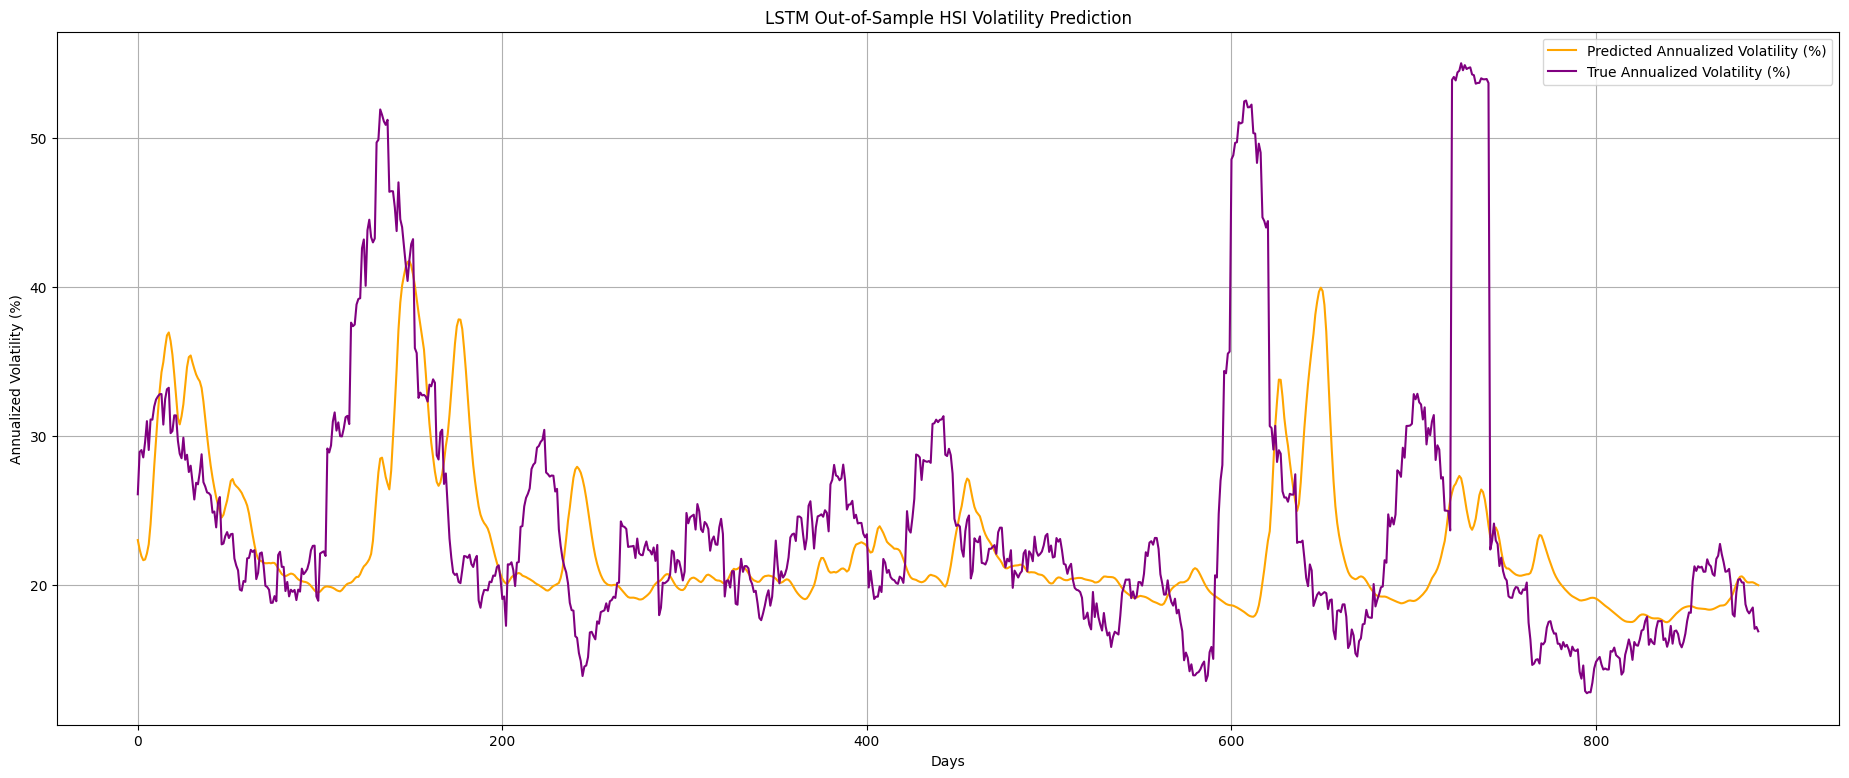

In [92]:
plt.figure(figsize=(23,9))
plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange') # CUHK Colors
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple') # CUHK Colors
plt.title('LSTM Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

### Compute Forecast Residuals

We calculate the forecast errors (residuals) in annualized percentage volatility units

In [93]:
# Forecast residuals: positive → model underestimates volatility
residuals = ann_true - ann_pred

### Visualizing LSTM Residuals

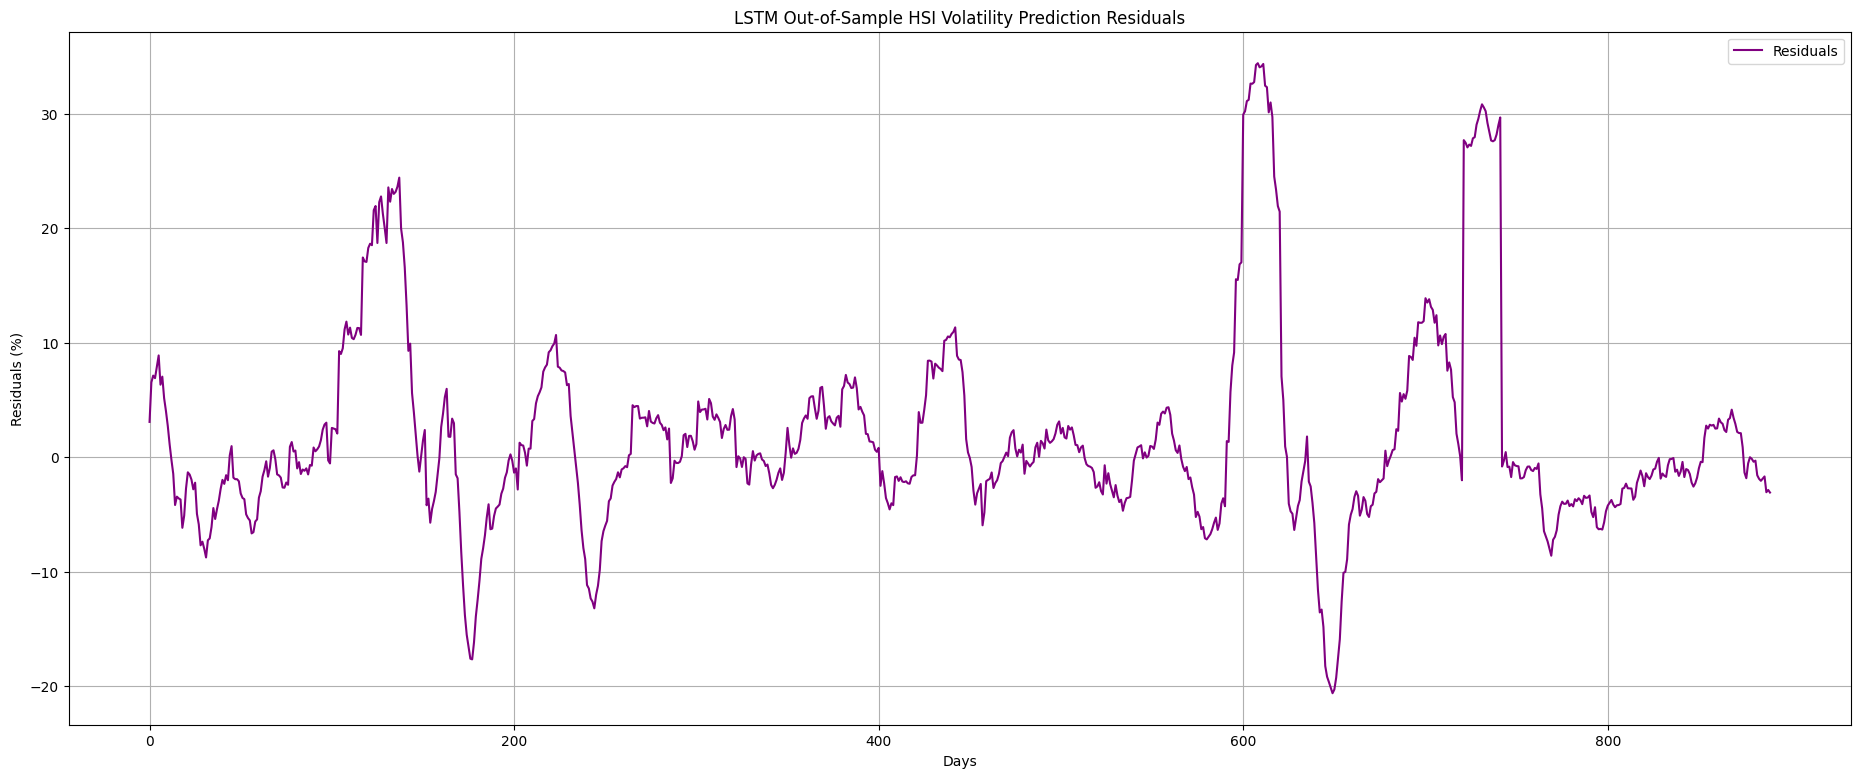

In [94]:
plt.figure(figsize=(23,9))
plt.plot(residuals, label='Residuals', color='purple')
plt.title('LSTM Out-of-Sample HSI Volatility Prediction Residuals') 
plt.xlabel('Days')
plt.ylabel('Residuals (%)')
plt.legend()
plt.grid()

### Export LSTM OOS Forecasts

In [95]:
# np.save("../results/LSTM_oos_preds.npy", preds)

### Leakage Check (Optional)

In [83]:
# predicitons = []
# oos_df['input'] = oos_df['2800.HK'].shift(1).dropna()

# for input in oos_df['input'].dropna():
#     print(input)
#     input = torch.tensor(input, dtype=torch.float32).view(1,1,1) # (1, seq_len, 1)
#     print('INPUT:',input)
#     print('PRED:',model(input).item())
#     predicitons.append(model(input).item())